TokaMaker Meshing Example: Building a mesh for SPARC {#doc_tMaker_SPARC_ex1}
==========
This is based on the open source SPARC device description published by Commonwealth Fusion Systems (CFS) in the [SPARCPublic](https://github.com/cfs-energy/SPARCPublic/) repository. SPARC is a compact high-field tokamak ($R_0 = 1.85$ m, $B_0 = 12.2$ T); the physics basis is described in the special series of seven papers in the Journal of Plasma Physics (2020), starting with Creely et al, "Overview of the SPARC tokamak", J. Plasma Phys. 86(5), 865860502. https://doi.org/10.1017/S0022377820001257

All files available on GitHub at: https://github.com/cfs-energy/SPARCPublic/

**Note:** as CFS states in the repository, the device description **is not an accurate description of the geometry of SPARC**. It is based on SPARC, but details protected by CFS' intellectual property have been removed or changed — in particular the division of the coils into turns is replaced by toy data. It is intended as a realistic example of an IMAS-schema geometry description for building example workflows, which is how we use it here.

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from matplotlib.path import Path
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library
To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the PYTHONPATH environment variable or using within a script using sys.path.append() as below, where we look for the environement variable OFT_ROOTPATH to provide the path to where the OpenFUSIONToolkit is installed (/Applications/OFT on macOS).

For meshing we will use the gs_Domain class to build a 2D triangular grid suitable for Grad-Shafranov equilibria. This class uses the triangle code through a python wrapper.

In [2]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit.TokaMaker.meshing import gs_Domain, save_gs_mesh

## Load geometry information
The geometry information (e.g. bounding curves for vacuum vessels) is loaded from a JSON file available in the [SPARCPublic](https://github.com/cfs-energy/SPARCPublic/) repository. The cell below reads the file directly from the repository over HTTP each time the notebook is run, so no copy of the device description is kept locally and the notebook always tracks the published version.

The SPARC description follows the **IMAS/OMAS data schema** (it was written with the [OMAS](https://gafusion.github.io/omas/index.html) library). CFS ship a `plot.py` alongside it that demonstrates the access patterns; we reproduce those here with the plain `json` library so the notebook has no extra dependencies. The fields we need are:

- `wall.description_2d[0]`: a *block* description of the vessel (`vessel.type.index == 1`), holding closed outlines of the structural sections of the inner and outer wall, plus `limiter.unit[0].outline`, the closed limiter (plasma-facing) contour
- `wall.description_2d[1]`: an *annular* description of the same two vessel walls (`vessel.type.index == 0`), giving `outline_inner` / `outline_outer` and a `resistivity` for each. This is the form `gs_Domain.add_annulus` wants, so it is what we use below
- `pf_active.coil`: the 22 PF/CS/DV/VS coils. Each coil is a list of `element`s whose geometry is an **`annulus`** — i.e. each turn is a *circular* filament at `(r, z)` with `radius_outer` (`radius_inner` is zero throughout), rather than a rectangular grid of filaments
- `pf_passive.loop`: the two passive shielding covers for the in-vessel vertical stability coils, each a closed `outline` polygon with a `resistivity`

In [3]:
import urllib.request

_SPARC_RAW = 'https://raw.githubusercontent.com/cfs-energy/SPARCPublic/main/DeviceDescription'

def fetch_json(filename):
    """Read a JSON file straight from the SPARCPublic repo, without writing it to disk."""
    print(f'Fetching {filename} from SPARCPublic...', end=' ', flush=True)
    with urllib.request.urlopen(f'{_SPARC_RAW}/{filename}') as resp:
        data = json.load(resp)
    print('done.')
    return data

mach = fetch_json('OS_SPARC_Device_Description.json')

print('Machine:', mach['dataset_description']['data_entry']['machine'],
      '| IMAS DD version:', mach['dataset_description']['dd_version'])
print('R0 =', mach['summary']['global_quantities']['r0']['value'], 'm')

Fetching OS_SPARC_Device_Description.json from SPARCPublic... done.
Machine: SPARC | IMAS DD version: 3.41.0
R0 = 1.8495 m


## Define coil array

In the SPARC file the turns are **circular filaments** (`geometry.annulus`), and two of the coils — the in-vessel vertical stability coils VS1U/VS1L — are **tilted** so that they follow the outboard vessel wall. An axis-aligned bounding rectangle around a tilted coil would spill outside the winding pack and, as it happens, cut straight through the VS coil covers.

We therefore take the **convex hull** of the filament circles (each circle sampled by a polygon of `nseg` points) as the coil boundary. This reduces to the expected octagonal-cornered box for the axis-aligned CS/PF/DV coils and correctly follows the tilt of the VS coils. The turn count is taken from the number of filament elements.

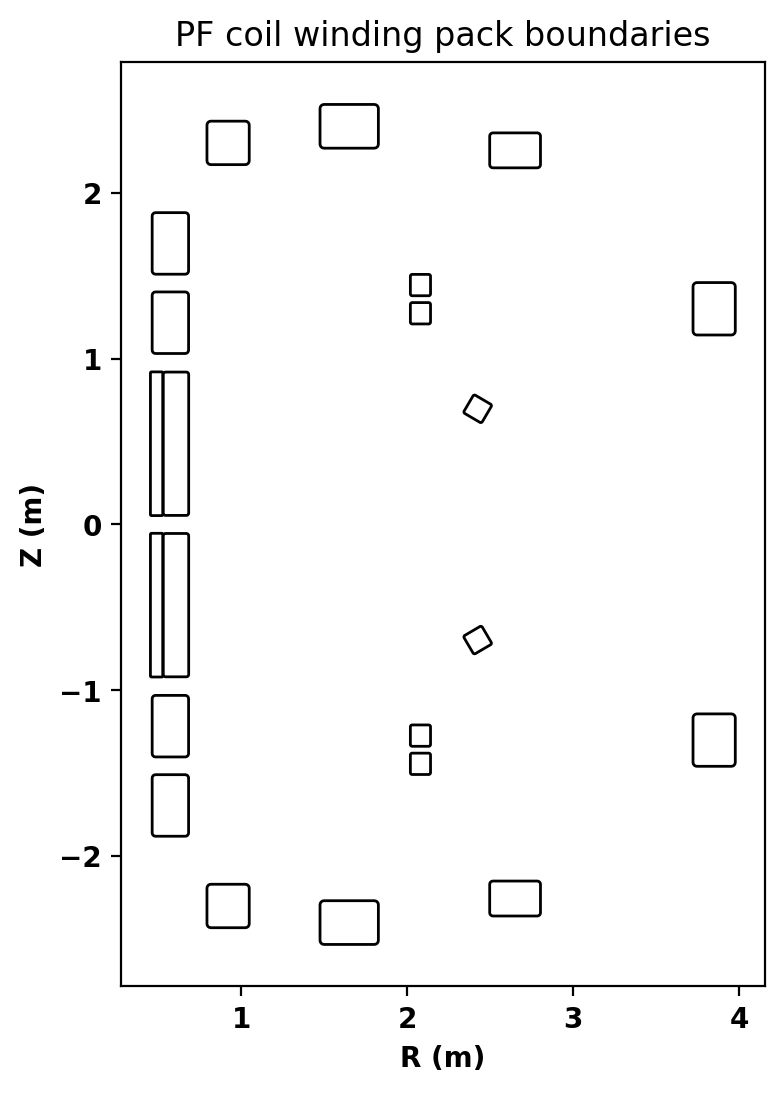

CS1UI     r=[0.4518, 0.5264]  z=[+0.0534, +0.9196]  n=280  turns_with_sign=+280
CS1UO     r=[0.5288, 0.6824]  z=[+0.0545, +0.9185]  n=135  turns_with_sign=+135
CS1LI     r=[0.4518, 0.5264]  z=[-0.9196, -0.0534]  n=280  turns_with_sign=+280
CS1LO     r=[0.5288, 0.6824]  z=[-0.9185, -0.0545]  n=135  turns_with_sign=+135
CS2U      r=[0.4622, 0.6818]  z=[+1.0305, +1.4015]  n= 40  turns_with_sign=+40
CS2L      r=[0.4622, 0.6818]  z=[-1.4015, -1.0305]  n= 40  turns_with_sign=+40
CS3U      r=[0.4622, 0.6818]  z=[+1.5085, +1.8795]  n= 40  turns_with_sign=+40
CS3L      r=[0.4622, 0.6818]  z=[-1.8795, -1.5085]  n= 40  turns_with_sign=+40
PF1U      r=[0.7926, 1.0474]  z=[+2.1690, +2.4310]  n= 25  turns_with_sign=+25
PF1L      r=[0.7926, 1.0474]  z=[-2.4310, -2.1690]  n= 25  turns_with_sign=+25
PF2U      r=[1.4741, 1.8259]  z=[+2.2682, +2.5318]  n= 30  turns_with_sign=+30
PF2L      r=[1.4741, 1.8259]  z=[-2.5318, -2.2682]  n= 30  turns_with_sign=+30
PF3U      r=[2.4969, 2.8031]  z=[+2.1496, +2.360

In [4]:
def coil_boundary(coil_elements, nseg=16):
    """Return the convex hull of a coil's filament circles, and the turn count.

    Each element is an IMAS "annulus": a circular filament at (r, z) with an outer
    radius. The hull of those circles bounds the winding pack, and unlike a bounding
    rectangle it stays tight around coils that are tilted (VS1U/VS1L).
    """
    pts = []
    for el in coil_elements:
        ann = el['geometry']['annulus']
        theta = np.linspace(0.0, 2.0*np.pi, nseg, endpoint=False)
        pts.append(np.column_stack((ann['r'] + ann['radius_outer']*np.cos(theta),
                                    ann['z'] + ann['radius_outer']*np.sin(theta))))
    pts = np.vstack(pts)
    hull = pts[ConvexHull(pts).vertices]
    return hull, len(coil_elements)


coil_data = {}
plt.figure()
for coil in mach['pf_active']['coil']:
    hull, n = coil_boundary(coil['element'])
    # turns_with_sign records the winding polarity of each turn (VS1L is wound in
    # the opposite sense); the mesh only needs the magnitude, the sign is carried
    # by the coil current in TokaMaker.
    turns_signed = sum(el['turns_with_sign'] for el in coil['element'])
    coil_data[coil['name']] = dict(hull=hull, n_filaments=n, turns_signed=turns_signed)
    plt.fill(hull[:,0], hull[:,1], facecolor='none', edgecolor='k', lw=1)

plt.gca().set_aspect('equal')
plt.xlabel('R (m)')
plt.ylabel('Z (m)')
plt.title('PF coil winding pack boundaries')
plt.show()

coil_name   = list(coil_data.keys())
coil_nturns = [coil_data[c]['n_filaments'] for c in coil_name]

for name in coil_name:
    c = coil_data[name]
    r = c['hull'][:,0]; z = c['hull'][:,1]
    print(f"{name:<8}  r=[{r.min():.4f}, {r.max():.4f}]  z=[{z.min():+.4f}, {z.max():+.4f}]"
          f"  n={c['n_filaments']:>3}  turns_with_sign={c['turns_signed']:+.0f}")

Here we check the resistivity of each element in the json, printing the results to the notebook. SPARC's description carries two conducting structures: the double-walled vacuum vessel (given in both block and annular form) and the two passive covers over the in-vessel VS coils.

In [5]:
for i, element in enumerate(mach['wall']['description_2d']):
    print(f"[{i}]", element['type'])
    if 'vessel' in element.keys():
        print(f"    vessel type: {element['vessel']['type']['description']}")
        print(f"    {len(element['vessel']['unit'])} items:")
        for item in element['vessel']['unit']:
            try:
                print(' -- ', item['name'], item['annular'].keys())
                print('    ', 'Resistivity:', item['annular']['resistivity'])
            except KeyError:
                print(' -- ', item['name'], f"({len(item['element'])} blocks)")
                print('    ', 'Resistivity:', item['element'][0]['resistivity'])

print()
print('pf_passive:')
for loop in mach['pf_passive']['loop']:
    print(' -- ', loop['name'])
    print('    ', 'Resistivity:', loop['resistivity'])

[0] {'description': 'Single limiter surface and block element vessel', 'index': 0}
    vessel type: Block description of the vessel
    2 items:
 --  inner wall (8 blocks)
     Resistivity: 8e-07
 --  outer wall (8 blocks)
     Resistivity: 8e-07
[1] {'description': 'Annular description of vessel (limiter field not filled)', 'index': -1}
    vessel type: Annular description of the vessel
    2 items:
 --  Vacuum vessel inner wall dict_keys(['outline_inner', 'outline_outer', 'resistivity'])
     Resistivity: 8e-07
 --  Vacuum vessel outer wall dict_keys(['outline_inner', 'outline_outer', 'resistivity'])
     Resistivity: 8e-07

pf_passive:
 --  Cover upper vertical stability coil
     Resistivity: 8e-07
 --  Cover lower vertical stability coil
     Resistivity: 8e-07


# Set mesh resolution for each region

First we define some target sizes to set the resolution in out grid. These variables will be used later and represent the target edge size within a given region, where units are in meters. In this case we are using a fairly coarse resolution for speed, but you can increase it for fidelity if needed.

In [6]:
plasma_res = 0.05   # target edge length inside the plasma (m)
coil_res   = 0.03   # PF coil regions
vv_res     = 0.02   # vacuum vessel walls
vac_res    = 0.06   # vacuum / air regions
cover_res  = 0.008  # VS coil covers (thin plates, only used if include_VS_covers = True)

## Define regions and attributes
We now create and define the various logical mesh regions. In the SPARC case we have 7 kinds of region:

- `air`: The region outside the outer vacuum vessel, which is not actually air in a superconducting device like SPARC but we use this terminology for commonality with present research devices. This is the outer bounding region and holds all of the CS, PF and DV coils
- `vac_vessel`: The vacuum gap between the inner and outer vacuum vessel walls
- `vac_inner`: The vacuum region inside the vacuum vessel but outside the limiter, which holds the in-vessel VS coils and their covers
- `plasma`: The region inside the limiter where the plasma will exist
- `vessel_inner`: The inner vacuum vessel wall
- `vessel_outer`: The outer vacuum vessel wall
- `vs_cover_upper` / `vs_cover_lower`: (optional) The passive shielding covers over the in-vessel VS coils
- `coil`: The 22 coils

Two SPARC-specific points are worth calling out, both of which follow from the geometry rather than from any choice we make:

- The **limiter is a distinct contour well inside the vessel**, so the plasma region is bounded by the limiter and a separate vacuum region (`vac_inner`) sits between the limiter and the inner vessel wall. In the ARC file the plasma region ran all the way to the inner vessel wall.
- The **DV1/DV2 divertor coils sit in the re-entrant divertor pocket**, which is topologically *outside* the vessel, so they belong to the `air` region despite visually appearing to be tucked inside the machine. Only VS1U/VS1L are genuinely in-vessel. Rather than hard-code this we assign each coil to its parent region by testing which contour contains it.

In [7]:
# Annular description of the vessel (description_2d entry with vessel.type.index == 0)
for i, dsc in enumerate(mach['wall']['description_2d']):
    if 'vessel' in dsc and dsc['vessel']['type']['index'] == 0:
        i_annular = i
vv_units = mach['wall']['description_2d'][i_annular]['vessel']['unit']

def annular_contours(unit):
    ann = unit['annular']
    inner = np.column_stack((ann['outline_inner']['r'], ann['outline_inner']['z']))
    outer = np.column_stack((ann['outline_outer']['r'], ann['outline_outer']['z']))
    return inner, outer

vv_inner_inner, vv_inner_outer = annular_contours(vv_units[0])   # inner wall
vv_outer_inner, vv_outer_outer = annular_contours(vv_units[1])   # outer wall

limiter_unit = mach['wall']['description_2d'][0]['limiter']['unit'][0]
limiter_contour = np.column_stack((limiter_unit['outline']['r'], limiter_unit['outline']['z']))

# Assign each coil to the region that contains it
path_vv_inner = Path(vv_inner_inner)   # inside the inner wall -> in-vessel
path_vv_outer = Path(vv_outer_inner)   # inside the outer wall -> inter-vessel gap

for name in coil_name:
    centroid = coil_data[name]['hull'].mean(axis=0)
    if path_vv_inner.contains_point(centroid):
        coil_data[name]['parent'] = 'vac_inner'
    elif path_vv_outer.contains_point(centroid):
        coil_data[name]['parent'] = 'vac_vessel'
    else:
        coil_data[name]['parent'] = 'air'

for parent in ('air', 'vac_vessel', 'vac_inner'):
    members = [n for n in coil_name if coil_data[n]['parent'] == parent]
    print(f'{parent:<11}: {len(members):>2} coils  {members}')

air        : 20 coils  ['CS1UI', 'CS1UO', 'CS1LI', 'CS1LO', 'CS2U', 'CS2L', 'CS3U', 'CS3L', 'PF1U', 'PF1L', 'PF2U', 'PF2L', 'PF3U', 'PF3L', 'PF4U', 'PF4L', 'DV1U', 'DV1L', 'DV2U', 'DV2L']
vac_vessel :  0 coils  []
vac_inner  :  2 coils  ['VS1U', 'VS1L']


In [8]:
gs_mesh = gs_Domain()

# Vacuum and plasma
gs_mesh.define_region('air',        vac_res,    'boundary')  # outer bounding box
gs_mesh.define_region('vac_vessel', vac_res,    'vacuum')    # gap between the two vessel walls
gs_mesh.define_region('vac_inner',  vac_res,    'vacuum')    # inside the vessel, outside the limiter
gs_mesh.define_region('plasma',     plasma_res, 'plasma')

# Vacuum vessel walls (inner and outer)
gs_mesh.define_region('vessel_inner', vv_res, 'conductor', vv_units[0]['annular']['resistivity'], allow_xpoints=True)
gs_mesh.define_region('vessel_outer', vv_res, 'conductor', vv_units[1]['annular']['resistivity'], allow_xpoints=True)

# The VS coil covers are thin plates, so including them is expensive; toggle as needed
include_VS_covers = True
cover_names = {}
for loop in mach['pf_passive']['loop']:
    cover_names[loop['name']] = 'vs_cover_upper' if 'upper' in loop['name'] else 'vs_cover_lower'
if include_VS_covers:
    for loop in mach['pf_passive']['loop']:
        gs_mesh.define_region(cover_names[loop['name']], cover_res, 'conductor',
                              loop['resistivity'], allow_xpoints=True)

# Coils — nTurns set to the filament count extracted from the device JSON
for name in coil_name:
    gs_mesh.define_region(name, coil_res, 'coil', nTurns=coil_data[name]['n_filaments'])

## Define geometry for region boundaries

Once the region types and properties are defined we now define the geometry of the mesh using shapes and references to the defined regions.

Working outward from the plasma: the limiter bounds the plasma; the inner vessel wall is an annulus separating `vac_inner` from `vac_vessel`; the outer vessel wall is an annulus separating `vac_vessel` from `air`. The coils and VS covers are then dropped into whichever region contains them.

In [9]:
# Plasma, bounded by the limiter contour
gs_mesh.add_polygon(limiter_contour, 'plasma', parent_name='vac_inner')

# Inner vacuum vessel
gs_mesh.add_annulus(vv_inner_inner, 'vac_inner',  vv_inner_outer, 'vessel_inner', parent_name='vac_vessel')

# Outer vacuum vessel
gs_mesh.add_annulus(vv_outer_inner, 'vac_vessel', vv_outer_outer, 'vessel_outer', parent_name='air')

# VS coil covers (optional)
if include_VS_covers:
    for loop in mach['pf_passive']['loop']:
        outline = loop['element'][0]['geometry']['outline']
        cover_contour = np.column_stack((outline['r'], outline['z']))
        gs_mesh.add_polygon(cover_contour, cover_names[loop['name']], parent_name='vac_inner')

# Coils — polygons from the extracted winding pack hulls
for name in coil_name:
    gs_mesh.add_polygon(coil_data[name]['hull'], name, parent_name=coil_data[name]['parent'])

## Plot topology

After defining the logical and physical topology we can now plot the curves within the definitions to double check everything is in the right place. In cases where curves appear to cross eachother (as with the VS coils and their covers) one should zoom in to ensure no crossings exist. Because we bound each coil by the convex hull of its filaments rather than by an axis-aligned rectangle, the tilted VS coils clear their covers and no curves needed to be moved for this example.

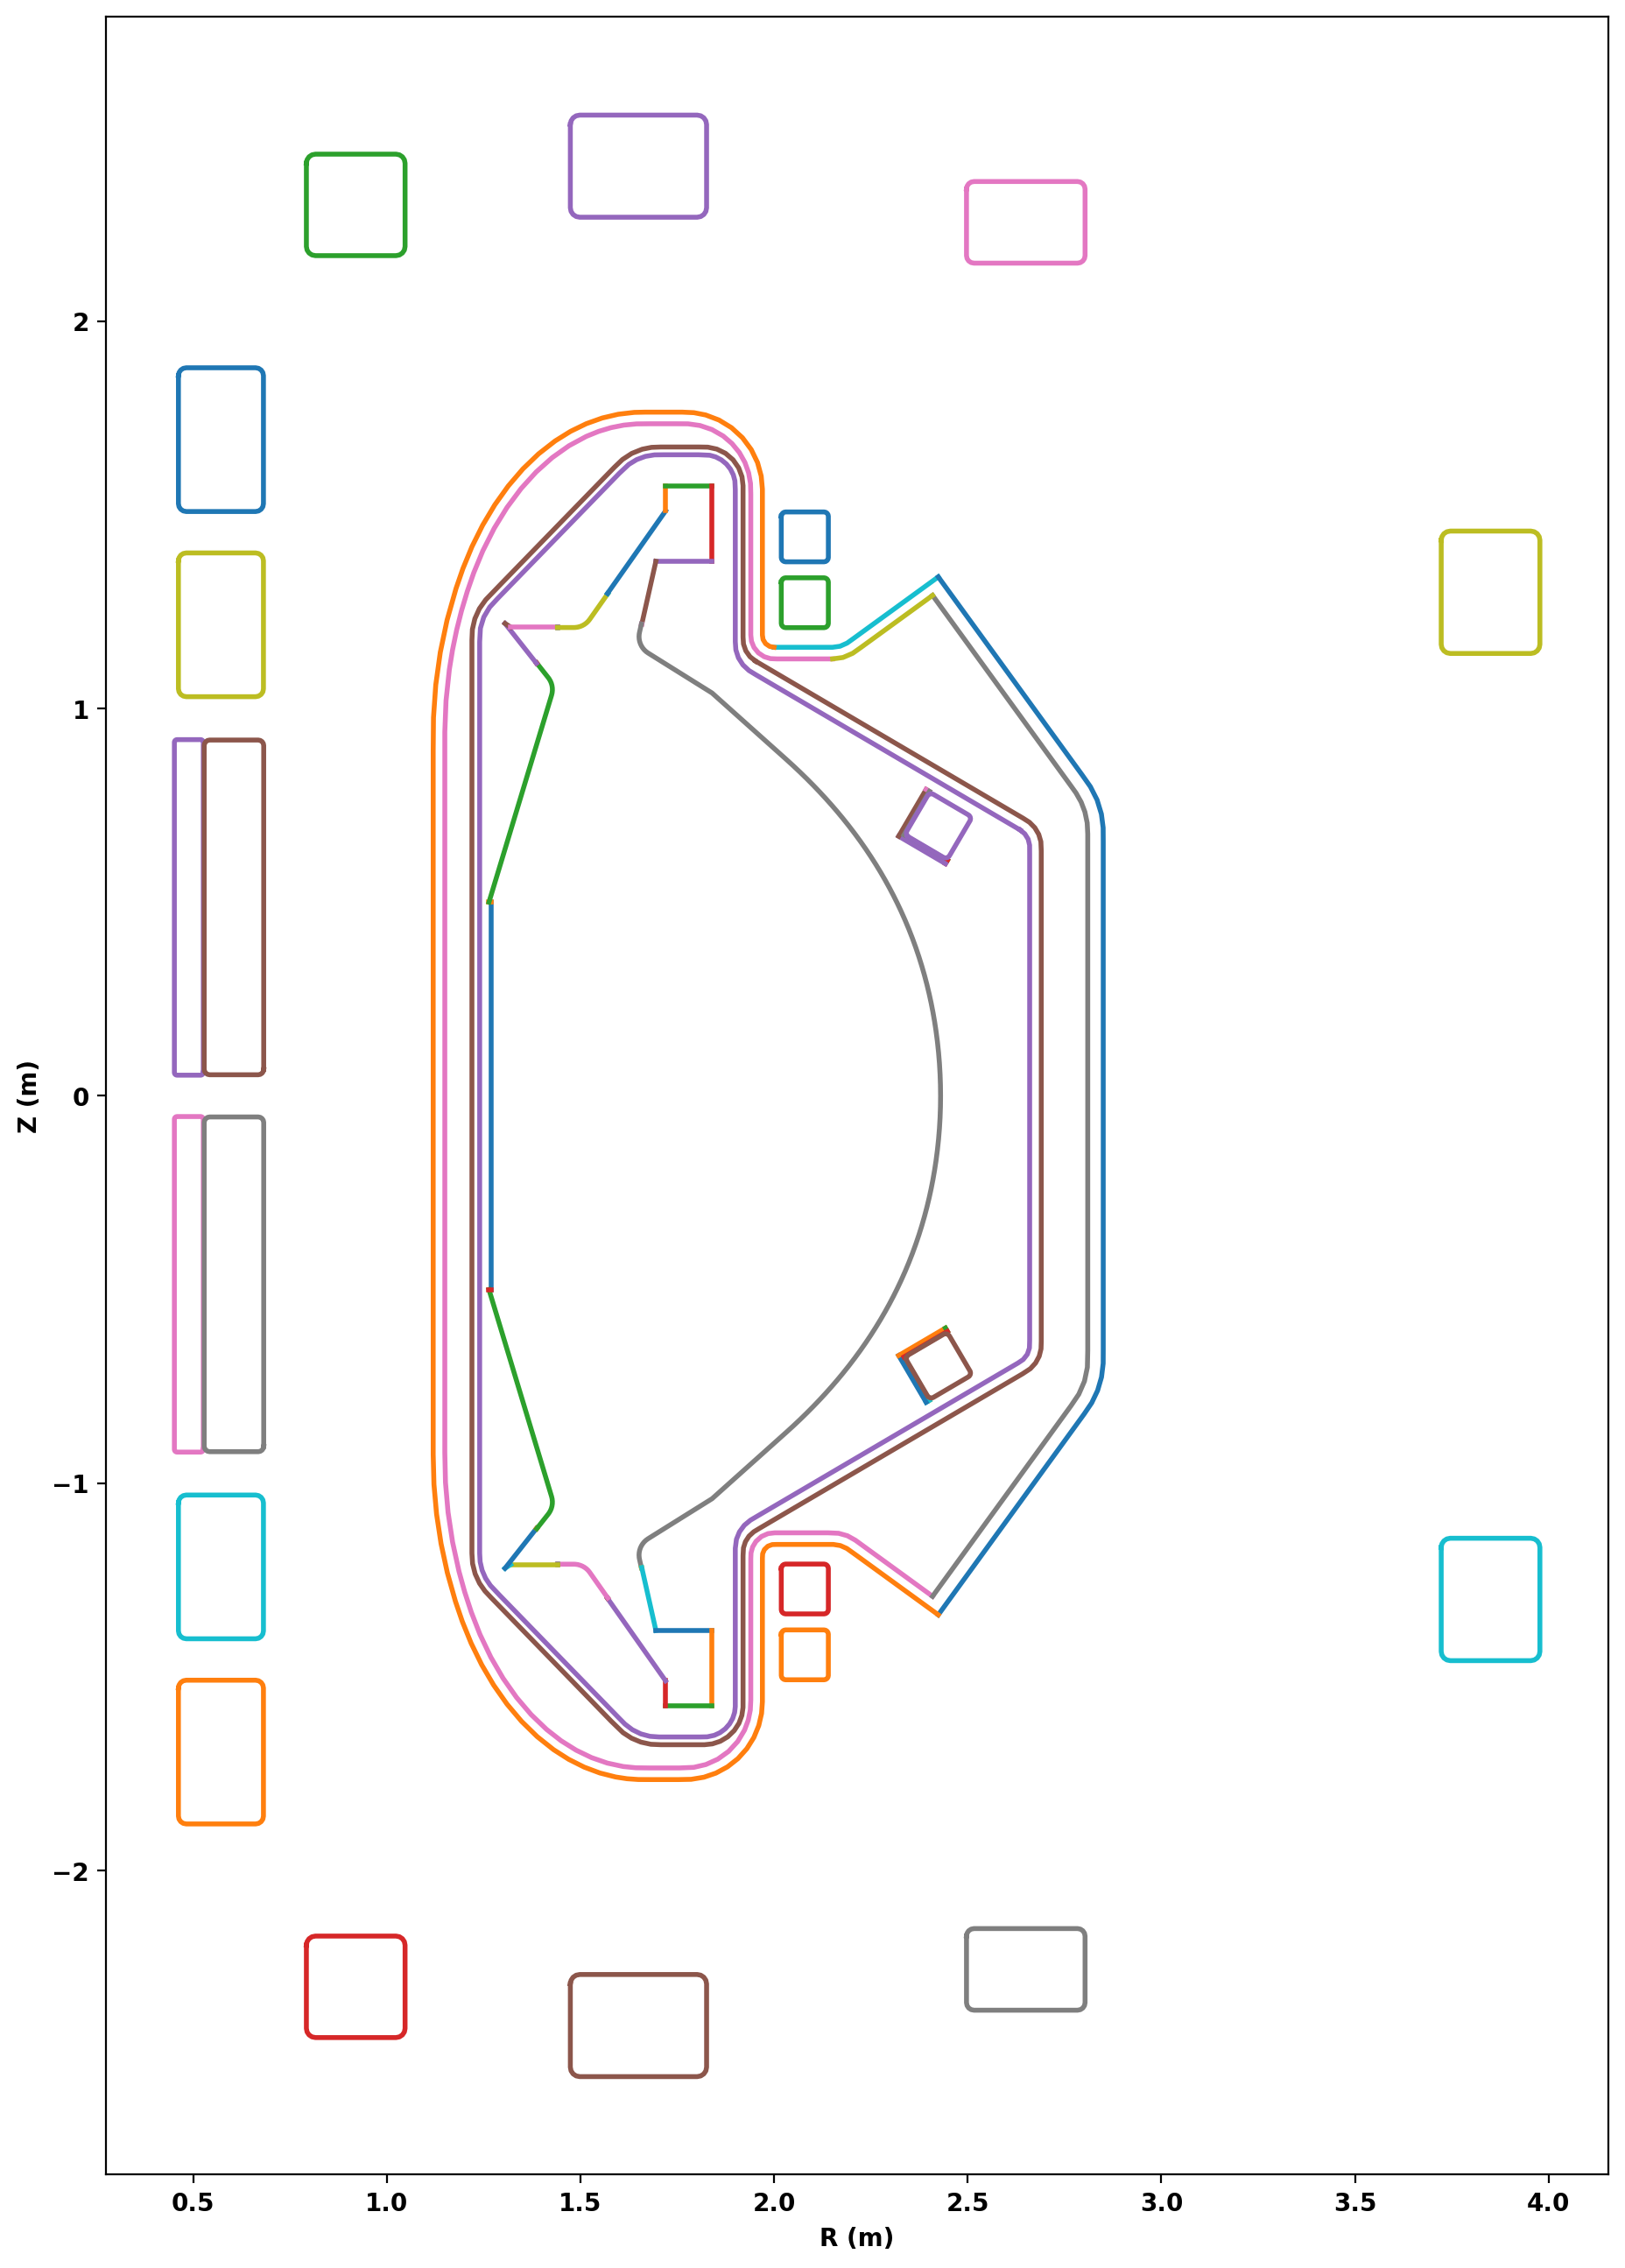

In [10]:
fig, ax = plt.subplots(1,1, figsize=(20,16))
gs_mesh.plot_topology(fig,ax)

## Create mesh

Now we generate the actual mesh using the `build_mesh` method. Additionally, since coil and conductor regions are defined, the `get_coils` and `get_conductors` methods should also be called to get descriptive dictionaries for later use in TokaMaker. This step may take a few moments as triangle generates the mesh.

The "small feature" warnings below come from the fine structure of the limiter contour in the divertor region, which is resolved more finely than our target plasma edge length; they are informational.

In [11]:
mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()
coil_dict = gs_mesh.get_coils()
cond_dict = gs_mesh.get_conductors()

Assembling regions:
  # of unique points    = 3225
  # of unique segments  = 80
Generating mesh with Triangle:
  # of points  = 18989
  # of cells   = 37616
  # of regions = 30


## Plot resulting regions and grid

We now plot the mesh by region to inspect proper generation.

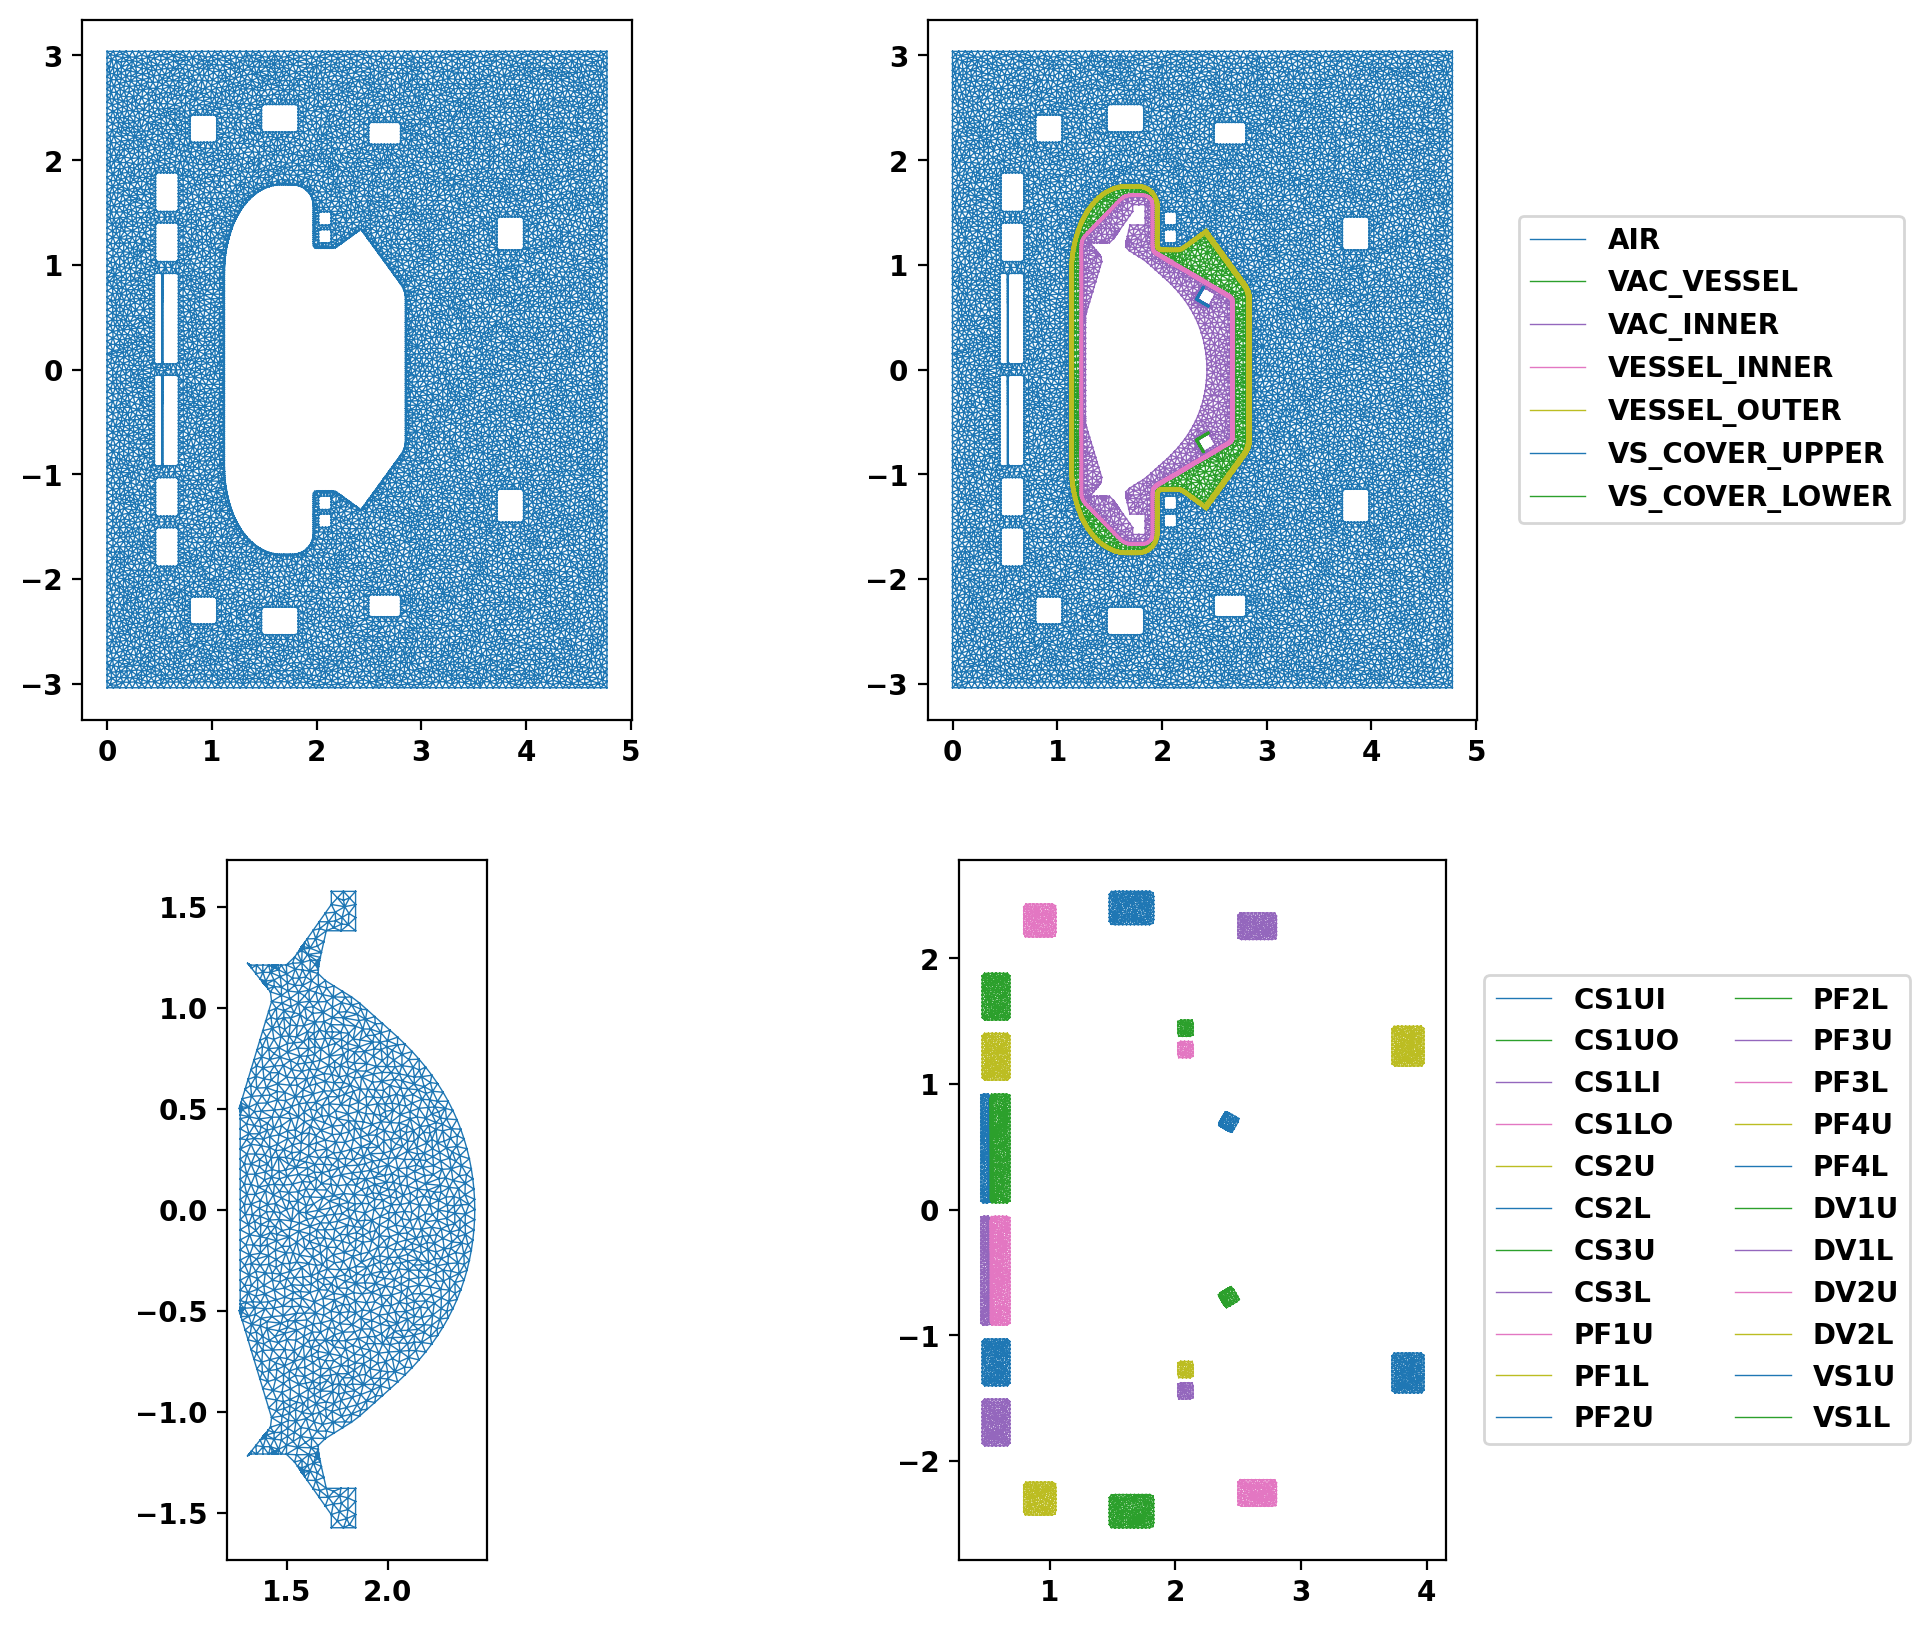

In [12]:
fig, ax = plt.subplots(2,2,figsize=(10,10))
ax[0,0].triplot(mesh_pts[:,0],mesh_pts[:,1],mesh_lc[mesh_reg==2,:],lw=0.5)  # plasma
ax[1,0].triplot(mesh_pts[:,0],mesh_pts[:,1],mesh_lc[mesh_reg==1,:],lw=0.5)  # air
for key, cond in cond_dict.items():
    ax[0,1].triplot(mesh_pts[:,0],mesh_pts[:,1],mesh_lc[mesh_reg==cond['reg_id'],:],lw=0.5,label=key)  # conductors
for key, coil in coil_dict.items():
    ax[1,1].triplot(mesh_pts[:,0],mesh_pts[:,1],mesh_lc[mesh_reg==coil['reg_id'],:],lw=0.5,label=key)  # coils
for ax_tmp in ax.flatten():
    ax_tmp.set_aspect('equal','box')
ax[0,1].legend(bbox_to_anchor=(1.05,0.5), loc='center left')
_ = ax[1,1].legend(bbox_to_anchor=(1.05,0.5), ncol=2, loc='center left')

plt.show()

Zooming in on the outboard midplane shows the in-vessel VS coil sitting between the limiter and the inner vessel wall, with its passive cover in front of it.

AIR
VAC_VESSEL
VAC_INNER
VESSEL_INNER
VESSEL_OUTER
VS_COVER_UPPER
VS_COVER_LOWER


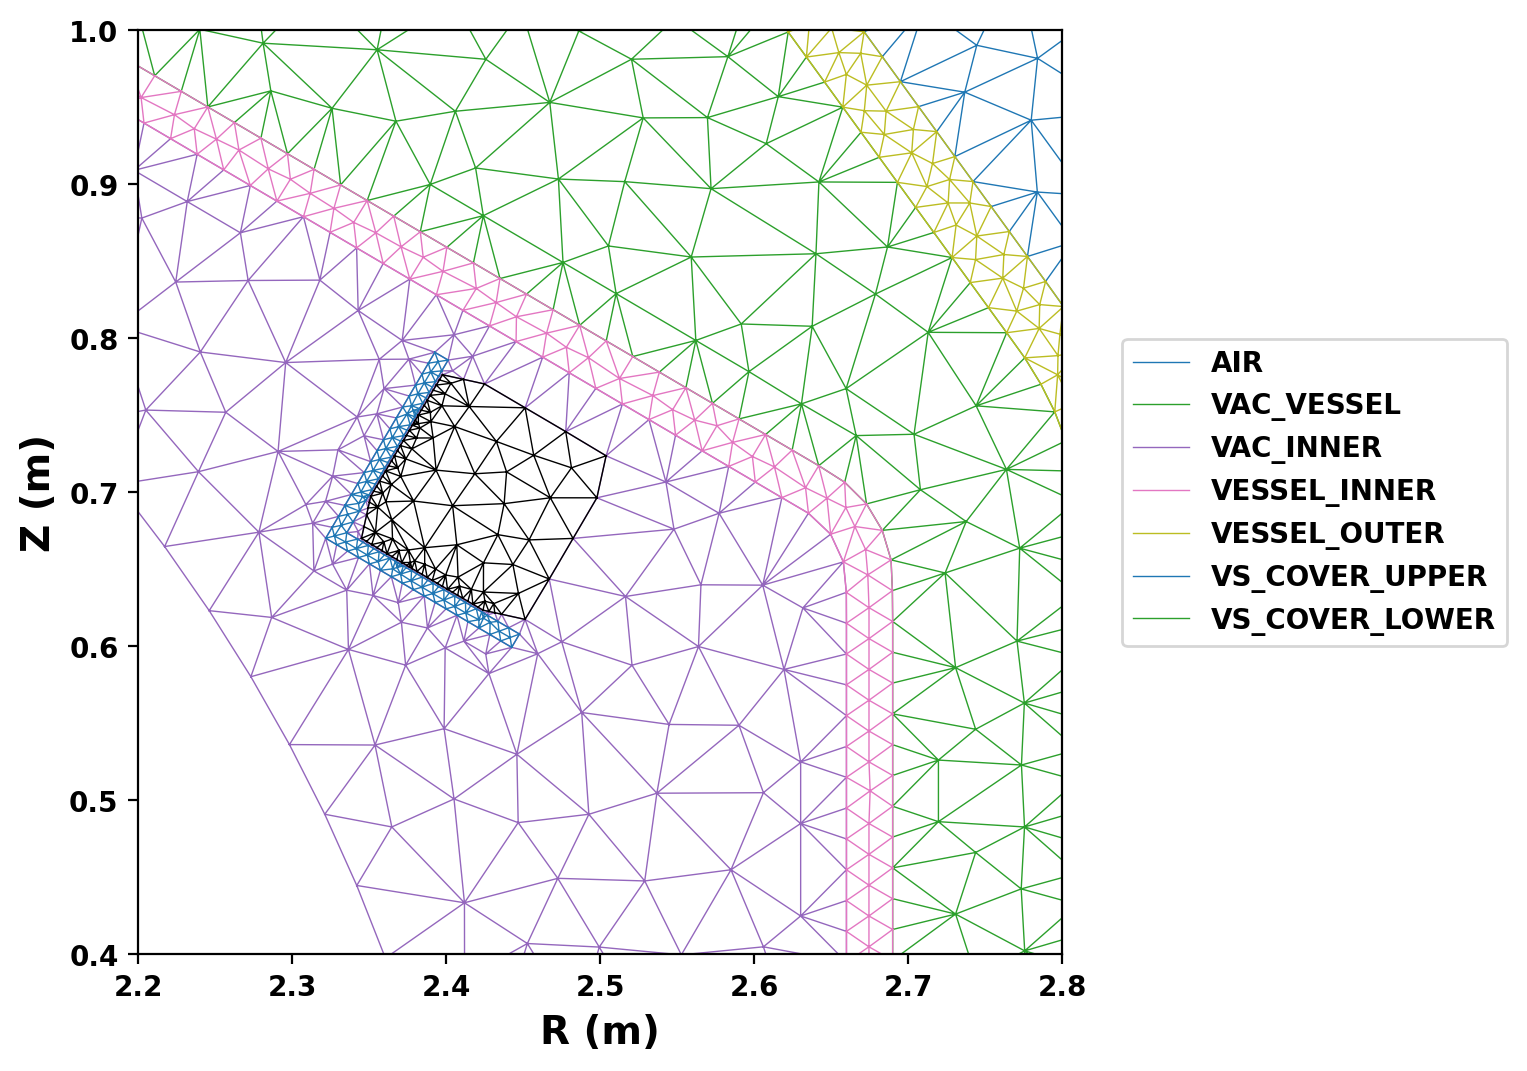

In [13]:
fig, ax = plt.subplots(1,1,figsize=(8,6))

for key, cond in cond_dict.items():
    print(key)
    ax.triplot(mesh_pts[:,0],mesh_pts[:,1],mesh_lc[mesh_reg==cond['reg_id'],:],lw=0.5,label=key)
for key, coil in coil_dict.items():
    ax.triplot(mesh_pts[:,0],mesh_pts[:,1],mesh_lc[mesh_reg==coil['reg_id'],:],lw=0.5,color='k')

ax.set_aspect('equal','box')
ax.set_xlim(2.2,2.8)
ax.set_ylim(0.4,1.0)
ax.legend(bbox_to_anchor=(1.05,0.5), loc='center left')
ax.set_xlabel('R (m)', fontsize=14)
ax.set_ylabel('Z (m)', fontsize=14)

plt.show()

## Save mesh for later use

As generation of the mesh often takes comparable, or longer, time compare to runs in TokaMaker it is useful to separate generation of the mesh into a different script as demonstrated here. The method `save_gs_mesh` can be used to save the resulting information for later use. This is done using and an HDF5 file through the h5py library.

In [14]:
fname = ''
# if include_VS_covers:
#     fname += '_withVScovers'

save_gs_mesh(mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict, f"sparc_public_mesh{fname}.h5")